In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from PIL import Image

In [2]:
# 1. Basic Parameter Setup
size = 512           # Simulation image size (pixels)
R = 21.41               # Short axis of rectangular aperture (equivalent to 20cm, keeping 10:1 ratio)


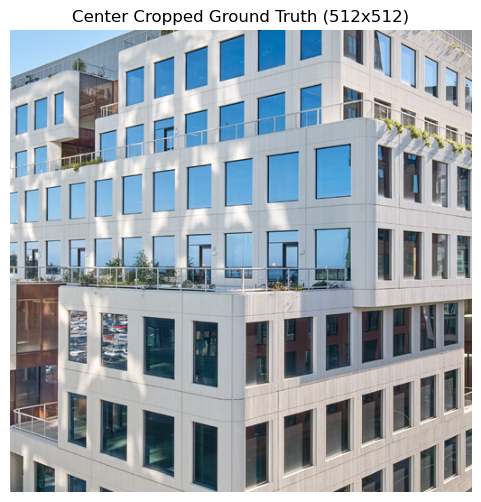

(512, 512, 3)


In [3]:
# 2. Get the ground truth image and crop to the center 512x512 region
img_full = Image.open("test3_1600_1200.jpg")
width, height = img_full.size
target_size = 512

left = (width - target_size) // 2
top = (height - target_size) // 2
right = left + target_size
bottom = top + target_size
img_cropped = img_full.crop((left, top, right, bottom))

# Convert to NumPy array and normalize to [0, 1] for the simulation
img = np.array(img_cropped).astype(float) / 255.0

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Center Cropped Ground Truth ({img.shape[1]}x{img.shape[0]})")
plt.axis('off')
plt.show()

print(img.shape)

In [4]:
# # 2. Get the ground truth image and crop to the center 512x512 region
# img_full = Image.open("test_882_588.jpg")
# width, height = img_full.size
# target_size = 512

# left = (width - target_size) // 2
# top = (height - target_size) // 2
# right = left + target_size
# bottom = top + target_size
# img_cropped = img_full.crop((left, top, right, bottom))

# # Convert to NumPy array and normalize to [0, 1] for the simulation
# img = np.array(img_cropped).astype(float) / 255.0

# plt.figure(figsize=(6, 6))
# plt.imshow(img)
# plt.title(f"Center Cropped Ground Truth ({img.shape[1]}x{img.shape[0]})")
# plt.axis('off')
# plt.show()

# print(img.shape)

In [5]:
def get_physical_aperture_round(size, R):
    y, x = np.meshgrid(np.linspace(-size//2, size//2, size), 
                       np.linspace(-size//2, size//2, size))
    rho = np.sqrt(x**2 + y**2)
    return (rho <= R).astype(float)

In [6]:
# 1. Generate the physical mask (2D)
mask = get_physical_aperture_round(size, R)

# 2. Simulate Imaging for RGB
# Create an empty array to store the result with the same shape as the input
blurred_img = np.zeros_like(img, dtype=float)

for i in range(3):  # Loop through R, G, and B channels
    channel = img[:, :, i]
    
    # Transform channel to frequency domain
    obj_fft = fftshift(fft2(channel))
    
    # Apply the Round Aperture mask
    filtered_fft = obj_fft * mask
    
    # Transform back and take the magnitude
    # We use .real or np.abs to get the intensity
    blurred_img[:, :, i] = np.abs(ifft2(fftshift(filtered_fft)))

# Normalize the result to [0, 1] if the input was floats, 
# or ensure it stays in the original range to prevent clipping
if img.max() > 1:
    blurred_img = np.clip(blurred_img, 0, 255).astype(np.uint8)
else:
    blurred_img = np.clip(blurred_img, 0, 1)

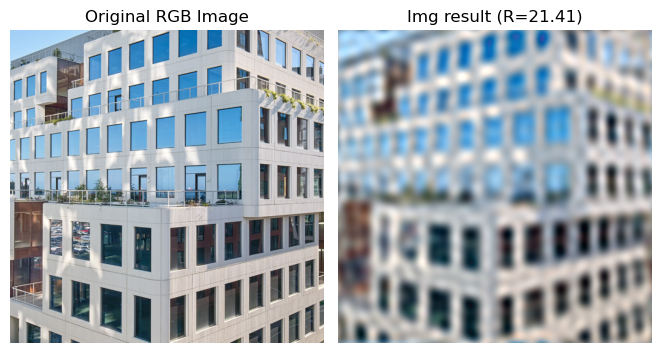

In [7]:
# 3. Plotting the Results
plt.figure(figsize=(10, 5))

# Subplot 1: The Original RGB Image
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original RGB Image")
plt.axis('off')

# Subplot 2: The Physical Aperture (The Mask)
plt.subplot(1, 3, 2)
plt.imshow(blurred_img)
plt.title(f"Img result (R={R})")
plt.axis('off')

plt.tight_layout()
plt.show()

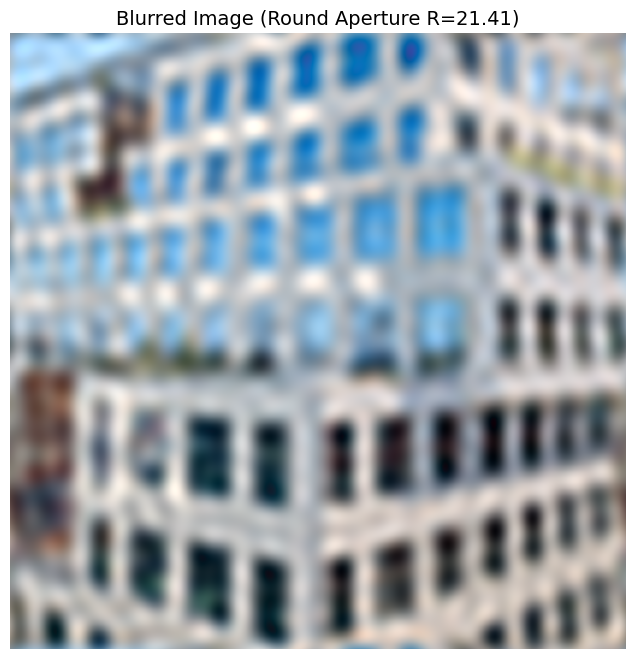

In [8]:
plot_ready_img = np.clip(blurred_img, 0, 1)

# 2. Create a dedicated figure for the blurred result
plt.figure(figsize=(8, 8))
plt.imshow(plot_ready_img)

# 3. Add styling
plt.title(f"Blurred Image (Round Aperture R={R})", fontsize=14)
plt.axis('off')  # Hide the pixel coordinate axes
plt.show()